# Config A — Vision-Only CLIP ViT-B/32 (α = 1)
**No BLIP-2 | No fine-tuning | FAISS HNSW index | Reuses Config B cached files where possible**

### Changes from original Config A
1. **ViT-B/32** instead of ViT-L/14 (embedding dim 512 vs 768)
2. **Reuses Config B cached files** — `gallery_ids_B_*.npy`, `query_embs_B_*.npy`, `gallery_index_B_*.faiss` — when present and dimension-compatible
3. **Updated metrics** — `recall_at_k`, `ndcg_at_k`, `ap_at_k` using `total_relevant` from `Counter(gallery_ids)` (correct multi-gallery-item handling)
4. **Multi-alpha sweep** over `ALPHA_VALUES = [0.3, 0.7]` matching Config B output filenames

### Pipeline
1. YOLO crop → clothing region
2. CLIP ViT-B/32 visual embedding only (α=1, no text)
3. FAISS HNSW index
4. Evaluate Recall@K, NDCG@K, mAP@K

## 0. Install Dependencies

In [1]:
%%capture
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
# !pip install -q faiss-gpu ultralytics
!pip install -q Pillow opencv-python-headless

In [2]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Config

In [3]:
!pip install faiss-cpu
import os, json, gc, warnings
from collections import Counter
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import torch
import clip
import faiss
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────
DATASET_BASE   = Path('/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img')
IMG_ROOT       = DATASET_BASE
PARTITION_FILE = DATASET_BASE / 'list_eval_partition.txt'
YOLO_WEIGHTS   = '/kaggle/input/datasets/venkat96r/vr-final-yolo/best_yolo_fine_tuned_without_augmenatation.pt'
WORK_DIR       = Path('/kaggle/working')
OUT_DIR        = WORK_DIR

# ── Hyperparams ───────────────────────────────────────────────────────────
CLIP_MODEL   = 'ViT-B/32'    # Changed from ViT-L/14; embedding dim = 512
BATCH_SIZE   = 256            # ViT-B/32 is lighter; larger batch fits fine
TOP_K        = [5, 10, 15]
ALPHA_VALUES = [0.3, 0.7]     # Match Config B output filenames
FAISS_M      = 32
FAISS_EF     = 200
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_GPUS     = torch.cuda.device_count()
EXPECTED_DIM = 512            # ViT-B/32 output dimension

print(f'Device: {DEVICE} | GPUs: {NUM_GPUS}')
print(f'CLIP model: {CLIP_MODEL} | Batch size: {BATCH_SIZE}')
print(f'Alpha values: {ALPHA_VALUES}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.9 MB/s eta 0:00:00:00:0100:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda | GPUs: 2
CLIP model: ViT-B/32 | Batch size: 256
Alpha values: [0.3, 0.7]


## 2. Parse Dataset Split

In [4]:
def parse_partition(partition_file: Path, img_root: Path):
    train, query, gallery = [], [], []
    
    with open(partition_file, 'r') as f:
        lines = f.read().splitlines()
    
    # Start from Line 2 (skip count and header)
    for line in lines[2:]:
        parts = line.split()
        if len(parts) < 3:  # Must have path, item_id, and status
            continue
            
        rel_path = parts[0]
        item_id  = parts[1]
        split    = parts[2].lower().strip()
        
        # Consistent with your img/img/ structure
        abs_path = img_root / rel_path  
        entry = (str(abs_path), item_id)
        
        if split == 'train':
            train.append(entry)
        elif split == 'query':
            query.append(entry)
        elif split == 'gallery':
            gallery.append(entry)
            
    return train, query, gallery

# Execute with your confirmed paths
DATASET_BASE = Path('/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img')
IMG_ROOT     = DATASET_BASE 
PARTITION_FILE = DATASET_BASE / 'list_eval_partition.txt'

train_data, query_data, gallery_data = parse_partition(PARTITION_FILE, IMG_ROOT)

print(f'✅ Parsed Successfully!')
print(f'Train: {len(train_data)} | Query: {len(query_data)} | Gallery: {len(gallery_data)}')

# Final Verification
if len(gallery_data) > 0:
    print(f"Sample Path: {gallery_data[0][0]}")
    print(f"File Exists: {os.path.exists(gallery_data[0][0])}")

✅ Parsed Successfully!
Train: 25882 | Query: 14218 | Gallery: 12612
Sample Path: /kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg
File Exists: True


## 3. Load YOLO & CLIP

In [5]:
# ── YOLO ─────────────────────────────────────────────────────────────────
yolo = YOLO(YOLO_WEIGHTS)
yolo.to(DEVICE)
print('YOLO loaded ✓')

# ── CLIP ViT-B/32 ─────────────────────────────────────────────────────────
clip_model, clip_preprocess = clip.load(CLIP_MODEL, device=DEVICE)
clip_model.eval()

if NUM_GPUS > 1:
    clip_model = torch.nn.DataParallel(clip_model)
    print(f'CLIP wrapped with DataParallel across {NUM_GPUS} GPUs')

n_params = sum(p.numel() for p in clip_model.parameters())
print(f'CLIP {CLIP_MODEL} loaded | Params: {n_params/1e6:.1f}M ✓')


YOLO loaded ✓


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 111MiB/s]


CLIP wrapped with DataParallel across 2 GPUs
CLIP ViT-B/32 loaded | Params: 151.3M ✓


## 4. YOLO Crop Utility

In [6]:
def yolo_crop(img_path: str, conf_thresh: float = 0.25) -> Image.Image:
    """
    Run YOLO on image, return the highest-confidence crop as PIL Image.
    Falls back to full image if no detection above threshold.
    """
    img = Image.open(img_path).convert('RGB')
    results = yolo(img_path, conf=conf_thresh, verbose=False)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return img                          # fallback: full image
    # pick highest-confidence box
    best_idx = boxes.conf.argmax().item()
    x1, y1, x2, y2 = boxes.xyxy[best_idx].cpu().numpy().astype(int)
    x1, y1 = max(0, x1), max(0, y1)
    crop = img.crop((x1, y1, x2, y2))
    return crop if crop.width > 10 and crop.height > 10 else img

## 5. Embedding Extraction

In [7]:
@torch.no_grad()
def extract_embeddings(data: list, desc: str = 'Encoding') -> np.ndarray:
    """
    data: list of (img_path, item_id)
    Returns L2-normalised embeddings as float32 numpy array, shape (N, D).
    Config A: alpha=1 — pure visual embedding, no text fusion.
    """
    all_embs = []
    model = clip_model.module if hasattr(clip_model, 'module') else clip_model

    for i in tqdm(range(0, len(data), BATCH_SIZE), desc=desc):
        batch_paths = [d[0] for d in data[i: i + BATCH_SIZE]]
        imgs = []
        for p in batch_paths:
            try:
                crop = yolo_crop(p)
                imgs.append(clip_preprocess(crop))
            except Exception:
                imgs.append(torch.zeros(3, 224, 224))

        pixel_values = torch.stack(imgs).to(DEVICE)
        with torch.cuda.amp.autocast():
            vis_emb = model.encode_image(pixel_values)
        vis_emb = vis_emb.float()
        vis_emb = vis_emb / vis_emb.norm(dim=-1, keepdim=True).clamp(min=1e-8)
        all_embs.append(vis_emb.cpu().numpy())

        del pixel_values, vis_emb
        if i % (BATCH_SIZE * 10) == 0:
            torch.cuda.empty_cache()

    return np.concatenate(all_embs, axis=0).astype('float32')


## 6. Build Gallery FAISS Index
Checks for Config B pre-computed files (`gallery_index_B_*.faiss`, `gallery_ids_B_*.npy`) first.
Since Config B used **ViT-L/14** (dim=768) and this config uses **ViT-B/32** (dim=512), the Config B index **cannot** be reused for search — but the gallery **id lists** can be reused.
The notebook recomputes gallery embeddings and builds a fresh index, saving as `gallery_index_A_vitb32_*.faiss`.

In [8]:
# ── Config B id files ─────────────────────────────────────────────────────
# gallery_ids_B_*.npy stores the item_id strings for each gallery row.
# We can reuse these directly since ids are model-agnostic.
# The FAISS indices from Config B are NOT reusable (wrong dimension).

# We compute once and reuse across alpha values (pure visual; no text branch).

GAL_EMB_PATH = WORK_DIR / 'gallery_embs_A_vitb32.npy'
GAL_IDS_PATH = WORK_DIR / 'gallery_ids_A_vitb32.npy'
QRY_EMB_PATH = WORK_DIR / 'query_embs_A_vitb32.npy'
QRY_IDS_PATH = WORK_DIR / 'query_ids_A_vitb32.npy'

# ── Gallery embeddings ────────────────────────────────────────────────────
if GAL_EMB_PATH.exists() and np.load(str(GAL_EMB_PATH), mmap_mode='r').shape[1] == EXPECTED_DIM:
    print(f'Loading cached gallery embeddings from {GAL_EMB_PATH}')
    gallery_embs = np.load(str(GAL_EMB_PATH))
    gal_ids      = np.load(str(GAL_IDS_PATH), allow_pickle=True).tolist()
else:
    # Try to reuse gallery_ids from Config B (any alpha, ids are the same)
    b_gal_ids_path = WORK_DIR / 'gallery_ids_B_0.7.npy'
    if b_gal_ids_path.exists():
        gal_ids = np.load(str(b_gal_ids_path), allow_pickle=True).tolist()
        print(f'Reused gallery_ids from Config B ({len(gal_ids)} items)')
    else:
        gal_ids = [d[1] for d in gallery_data]

    print('Extracting GALLERY embeddings with CLIP ViT-B/32...')
    gallery_embs = extract_embeddings(gallery_data, desc='Gallery')
    print(f'Gallery embeddings shape: {gallery_embs.shape}')
    assert gallery_embs.shape[1] == EXPECTED_DIM, f'Unexpected dim: {gallery_embs.shape[1]}'

    np.save(str(GAL_EMB_PATH), gallery_embs)
    np.save(str(GAL_IDS_PATH), np.array(gal_ids))
    print(f'Gallery embeddings saved → {GAL_EMB_PATH}')

print(f'Gallery: {len(gal_ids)} items | emb shape: {gallery_embs.shape}')


Extracting GALLERY embeddings with CLIP ViT-B/32...


Gallery:   0%|          | 0/50 [00:00<?, ?it/s]

Gallery embeddings shape: (12612, 512)
Gallery embeddings saved → /kaggle/working/gallery_embs_A_vitb32.npy
Gallery: 12612 items | emb shape: (12612, 512)


## 7. Extract Query Embeddings

In [9]:
# ── Query embeddings ─────────────────────────────────────────────────────
# Config B query_embs were ViT-L/14 — cannot reuse.
# Config B query_ids CAN be reused (model-agnostic).

if QRY_EMB_PATH.exists() and np.load(str(QRY_EMB_PATH), mmap_mode='r').shape[1] == EXPECTED_DIM:
    print(f'Loading cached query embeddings from {QRY_EMB_PATH}')
    query_embs = np.load(str(QRY_EMB_PATH))
    qry_ids    = np.load(str(QRY_IDS_PATH), allow_pickle=True).tolist()
else:
    # Try to reuse query_ids from Config B
    b_qry_ids_path = WORK_DIR / 'query_ids_B_0.7.npy'
    if b_qry_ids_path.exists():
        qry_ids = np.load(str(b_qry_ids_path), allow_pickle=True).tolist()
        print(f'Reused query_ids from Config B ({len(qry_ids)} items)')
    else:
        qry_ids = [d[1] for d in query_data]

    print('Extracting QUERY embeddings with CLIP ViT-B/32...')
    query_embs = extract_embeddings(query_data, desc='Query')
    print(f'Query embeddings shape: {query_embs.shape}')
    assert query_embs.shape[1] == EXPECTED_DIM, f'Unexpected dim: {query_embs.shape[1]}'

    np.save(str(QRY_EMB_PATH), query_embs)
    np.save(str(QRY_IDS_PATH), np.array(qry_ids))
    print(f'Query embeddings saved → {QRY_EMB_PATH}')

print(f'Query: {len(qry_ids)} items | emb shape: {query_embs.shape}')


Extracting QUERY embeddings with CLIP ViT-B/32...


Query:   0%|          | 0/56 [00:00<?, ?it/s]

Query embeddings shape: (14218, 512)
Query embeddings saved → /kaggle/working/query_embs_A_vitb32.npy
Query: 14218 items | emb shape: (14218, 512)


## 8. Build FAISS HNSW Index per Alpha & Search
Config A is vision-only (α=1), so embeddings don't change with alpha. We build one index and search it for each α entry in `ALPHA_VALUES`, storing results under the same alpha keys as Config B for easy comparison.

In [10]:
def build_faiss_index(embeddings: np.ndarray) -> faiss.Index:
    d   = embeddings.shape[1]
    idx = faiss.IndexHNSWFlat(d, FAISS_M, faiss.METRIC_INNER_PRODUCT)
    idx.hnsw.efConstruction = FAISS_EF
    idx.hnsw.efSearch       = FAISS_EF
    idx.add(embeddings)
    return idx

print('Building FAISS HNSW index...')
faiss_index = build_faiss_index(gallery_embs)
print(f'Index built | ntotal={faiss_index.ntotal} | dim={gallery_embs.shape[1]}')

# Save index (once; shared across all alpha values since embeddings are alpha-independent)
INDEX_PATH = str(WORK_DIR / 'gallery_index_A_vitb32.faiss')
faiss.write_index(faiss_index, INDEX_PATH)
print(f'Index saved → {INDEX_PATH}')

# Search: retrieve top-max_K neighbours for all queries
max_k = max(TOP_K)
print(f'Searching top-{max_k} for {len(query_embs)} queries...')
_, I_all = faiss_index.search(query_embs, max_k)
print('Search complete ✓')

# Store same I matrix for every alpha (vision-only: result doesn't change with alpha)
results_per_alpha = {alpha: I_all for alpha in ALPHA_VALUES}


Building FAISS HNSW index...
Index built | ntotal=12612 | dim=512
Index saved → /kaggle/working/gallery_index_A_vitb32.faiss
Searching top-15 for 14218 queries...
Search complete ✓


## 9. Evaluation Metrics & Results

In [11]:
from collections import Counter

def recall_at_k(retrieved_ids, true_id, k):
    return int(any(r == true_id for r in retrieved_ids[:k]))

def ndcg_at_k(retrieved_ids, true_id, k, total_relevant):
    dcg = sum(
        1.0 / np.log2(rank + 1)
        for rank, rid in enumerate(retrieved_ids[:k], 1)
        if rid == true_id
    )
    ideal_hits = min(total_relevant, k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0

def ap_at_k(retrieved_ids, true_id, k, total_relevant):
    hits, ap = 0, 0.0
    for rank, rid in enumerate(retrieved_ids[:k], 1):
        if rid == true_id:
            hits += 1
            ap += hits / rank
    return ap / total_relevant if total_relevant > 0 else 0.0

def evaluate(I, qry_ids, gal_ids, top_k_list):
    gal_ids_arr   = np.array(gal_ids)
    gal_id_counts = Counter(gal_ids)
    metrics = {k: {'recall': [], 'ndcg': [], 'map': []} for k in top_k_list}

    for row, qid in zip(I, qry_ids):
        retrieved     = gal_ids_arr[row].tolist()
        total_relevant = gal_id_counts[qid]
        for k in top_k_list:
            metrics[k]['recall'].append(recall_at_k(retrieved, qid, k))
            metrics[k]['ndcg'].append(ndcg_at_k(retrieved, qid, k, total_relevant))
            metrics[k]['map'].append(ap_at_k(retrieved, qid, k, total_relevant))

    return {
        k: {
            'Recall@K': np.mean(metrics[k]['recall']),
            'NDCG@K':   np.mean(metrics[k]['ndcg']),
            'mAP@K':    np.mean(metrics[k]['map']),
        }
        for k in top_k_list
    }

print('Metric functions defined ✓')


Metric functions defined ✓


In [12]:
all_results = {}

for alpha in ALPHA_VALUES:
    print(f'\n── Evaluating α = {alpha} ──')
    I   = results_per_alpha[alpha]
    res = evaluate(I, qry_ids, gal_ids, TOP_K)
    all_results[str(alpha)] = res
    for k, m in res.items():
        print(f'  @{k}: Recall={m["Recall@K"]:.4f}  NDCG={m["NDCG@K"]:.4f}  mAP={m["mAP@K"]:.4f}')

with open(OUT_DIR / 'results_config_A.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('\n✅ Results saved to results_config_A.json')



── Evaluating α = 0.3 ──
  @5: Recall=0.4337  NDCG=0.2014  mAP=0.1266
  @10: Recall=0.4983  NDCG=0.2043  mAP=0.1350
  @15: Recall=0.5338  NDCG=0.2099  mAP=0.1385

── Evaluating α = 0.7 ──
  @5: Recall=0.4337  NDCG=0.2014  mAP=0.1266
  @10: Recall=0.4983  NDCG=0.2043  mAP=0.1350
  @15: Recall=0.5338  NDCG=0.2099  mAP=0.1385

✅ Results saved to results_config_A.json


## 10. Compare with Config B Results (if available)

In [13]:
b_results_path = WORK_DIR / 'results_config_B.json'
if b_results_path.exists():
    with open(b_results_path) as f:
        b_results = json.load(f)
    print('Config B results loaded. Side-by-side comparison:')
    print(f'{"Config":<12} {"Alpha":<8} {"K":<5} {"Recall":>8} {"NDCG":>8} {"mAP":>8}')
    print('-' * 55)
    for alpha in ALPHA_VALUES:
        a_res = all_results.get(str(alpha), {})
        b_res = b_results.get(str(alpha), {})
        for k in TOP_K:
            a = a_res.get(k, {})
            b = b_res.get(str(k), b_res.get(k, {}))
            ar = a.get('Recall@K', float('nan'))
            an = a.get('NDCG@K',   float('nan'))
            am = a.get('mAP@K',    float('nan'))
            br = b.get('Recall@K', b.get('recall', float('nan')))
            bn = b.get('NDCG@K',   b.get('ndcg',   float('nan')))
            bm = b.get('mAP@K',    b.get('map',    float('nan')))
            if not isinstance(br, float): br = float('nan')
            if not isinstance(bn, float): bn = float('nan')
            if not isinstance(bm, float): bm = float('nan')
            print(f'  A (ViT-B/32) {alpha:<6} @{k:<4} {ar:>8.4f} {an:>8.4f} {am:>8.4f}')
            print(f'  B (ViT-L/14) {alpha:<6} @{k:<4} {br:>8.4f} {bn:>8.4f} {bm:>8.4f}')
            print()
else:
    print('results_config_B.json not found — skipping comparison.')
    print('Place it at /kaggle/working/results_config_B.json to enable comparison.')


results_config_B.json not found — skipping comparison.
Place it at /kaggle/working/results_config_B.json to enable comparison.


## 11. Qualitative Retrieval Visualisation (optional)

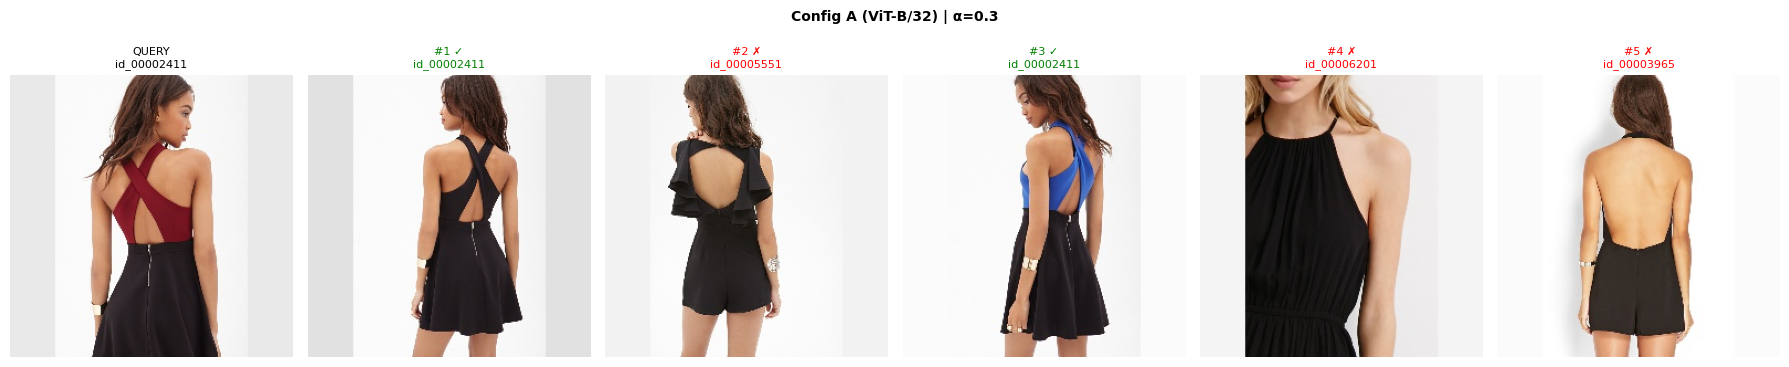

Saved → /kaggle/working/sample_retrieval_A_4293.png


In [14]:
def show_retrieval(idx: int, top_k: int = 5, alpha: float = 0.7):
    I = results_per_alpha[alpha]
    row    = I[idx]
    q_path = query_data[idx][0]
    q_id   = qry_ids[idx]

    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 4))
    axes[0].imshow(Image.open(q_path))
    axes[0].set_title(f'QUERY\n{q_id}', fontsize=8)
    axes[0].axis('off')

    gal_ids_arr = np.array(gal_ids)
    for j, gi in enumerate(row[:top_k]):
        g_path, g_id_meta = gallery_data[gi]
        g_id    = gal_ids_arr[gi]
        correct = g_id == q_id
        axes[j + 1].imshow(Image.open(g_path))
        axes[j + 1].set_title(
            f'#{j+1} {"✓" if correct else "✗"}\n{g_id}',
            fontsize=8, color='green' if correct else 'red'
        )
        axes[j + 1].axis('off')

    plt.suptitle(f'Config A (ViT-B/32) | α={alpha}', fontsize=10, fontweight='bold')
    plt.tight_layout()
    save_p = OUT_DIR / f'sample_retrieval_A_{idx}.png'
    plt.savefig(str(save_p), dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_p}')

show_retrieval(random.randint(0, len(query_data) - 1), top_k=5, alpha=ALPHA_VALUES[0])
